In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Load PDE data and matched-control catalogue.
pde_df = pd.read_csv('output/pde/catalogue/events_with_metrics.csv')
control_df = pd.read_csv('output/pde/controls/controls_with_metrics.csv')

metrics = [
    'pass_acc_ratio', 'fwd_pass_ratio', 'long_ball_ratio', 'xg_rate',
    'shot_rate', 'avg_xg', 'dribble_rate', 'turnover_rate',
    'foul_rate', 'press_intensity'
]

event_types = ['Big Miss', 'Selfish Shot', 'Yellow Card', 'Wasted Turnover', 'Shock Goal']

# Compute matched-control adjusted deltas.
control_deltas = []
for metric in metrics:
    delta_col = f'delta_{metric}'
    avg_ctrl = control_df.groupby('paired_event_id')[delta_col].mean().rename(f'avg_ctrl_delta_{metric}')
    control_deltas.append(avg_ctrl)

control_agg_df = pd.concat(control_deltas, axis=1).reset_index()
control_agg_df.rename(columns={'paired_event_id': 'event_id'}, inplace=True)

pde_adj_df = pde_df.merge(control_agg_df, on='event_id', how='left')
for metric in metrics:
    pde_adj_df[f'adj_delta_{metric}'] = pde_adj_df[f'delta_{metric}'] - pde_adj_df[f'avg_ctrl_delta_{metric}']

# Standardize severity within event type before testing.
pde_adj_df['severity_std'] = (
    pde_adj_df.groupby('event_type')['severity']
    .transform(lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) != 0 else 0.0)
    .fillna(0.0)
)

# Run the original specification: per event type x metric Spearman rho.
correlation_results = []
for event in event_types:
    event_data = pde_adj_df[pde_adj_df['event_type'] == event].copy()
    for metric in metrics:
        adj_delta_col = f'adj_delta_{metric}'
        valid_data = event_data[['severity_std', adj_delta_col]].dropna()

        if len(valid_data) < 5:
            rho, p_val = np.nan, np.nan
        else:
            rho, p_val = spearmanr(valid_data['severity_std'], valid_data[adj_delta_col])

        correlation_results.append({
            'event_type': event,
            'metric': metric,
            'n_obs': len(valid_data),
            'spearman_rho': rho,
            'p_value_raw': p_val
        })

corr_df = pd.DataFrame(correlation_results)
reject, pvals_corrected, _, _ = multipletests(
    pvals=corr_df['p_value_raw'].fillna(1.0),
    alpha=0.05,
    method='fdr_bh'
)

corr_df['p_value_fdr'] = pvals_corrected
corr_df['is_significant'] = reject

corr_df.to_csv('output/pde/analysis/severity_correlation_results.csv', index=False, encoding='utf-8-sig')

print('\nSeverity correlation table')
print(corr_df.sort_values('p_value_raw', na_position='last').head(10).to_string(index=False))
print(f'\nFDR-significant count: {int(corr_df["is_significant"].sum())}')


=== Severity correlation table ===
     event_type          metric  n_obs  spearman_rho  p_value_raw  p_value_fdr  is_significant
Wasted Turnover       shot_rate   1459     -0.111313     0.000020     0.001016            True
Wasted Turnover          avg_xg   1459     -0.080616     0.002059     0.046936            True
Wasted Turnover         xg_rate   1459     -0.078151     0.002816     0.046936            True
Wasted Turnover  pass_acc_ratio   1459     -0.074869     0.004219     0.052734           False
       Big Miss       shot_rate    293     -0.148768     0.010778     0.107782           False
     Shock Goal press_intensity    149      0.190262     0.020117     0.167645           False
     Shock Goal   turnover_rate    149     -0.173497     0.034342     0.245298           False
       Big Miss         xg_rate    293     -0.119895     0.040276     0.251725           False
   Selfish Shot   turnover_rate    177     -0.137199     0.068607     0.372477           False
       Big Mis

In [ ]:
# Optional diagnostic summary by event type.
summary_by_event = (
    corr_df.groupby('event_type')
    .agg(
        n_obs=('n_obs', 'sum'),
        strongest_abs_rho=('spearman_rho', lambda s: np.abs(s).max() if s.notna().any() else np.nan),
        best_raw_p=('p_value_raw', lambda s: s.min() if s.notna().any() else np.nan),
        significant_pairs=('is_significant', 'sum')
    )
    .reset_index()
)

print('\nSeverity correlation diagnostics')
print(summary_by_event.sort_values(['strongest_abs_rho', 'best_raw_p'], ascending=[False, True]).to_string(index=False))
print('\nFDR-significant pairs')
print(corr_df.loc[corr_df['is_significant'], ['event_type', 'metric', 'n_obs', 'spearman_rho', 'p_value_fdr']].to_string(index=False))


=== Severity correlation diagnostics ===
     event_type  n_obs  strongest_abs_rho  best_raw_p  significant_pairs
     Shock Goal   1490           0.190262    0.020117                  0
       Big Miss   2930           0.148768    0.010778                  0
   Selfish Shot   1770           0.137199    0.068607                  0
Wasted Turnover  14590           0.111313    0.000020                  3
    Yellow Card  13710           0.043872    0.104430                  0

=== FDR-significant pairs ===
     event_type    metric  n_obs  spearman_rho  p_value_fdr
Wasted Turnover   xg_rate   1459     -0.078151     0.046936
Wasted Turnover shot_rate   1459     -0.111313     0.001016
Wasted Turnover    avg_xg   1459     -0.080616     0.046936


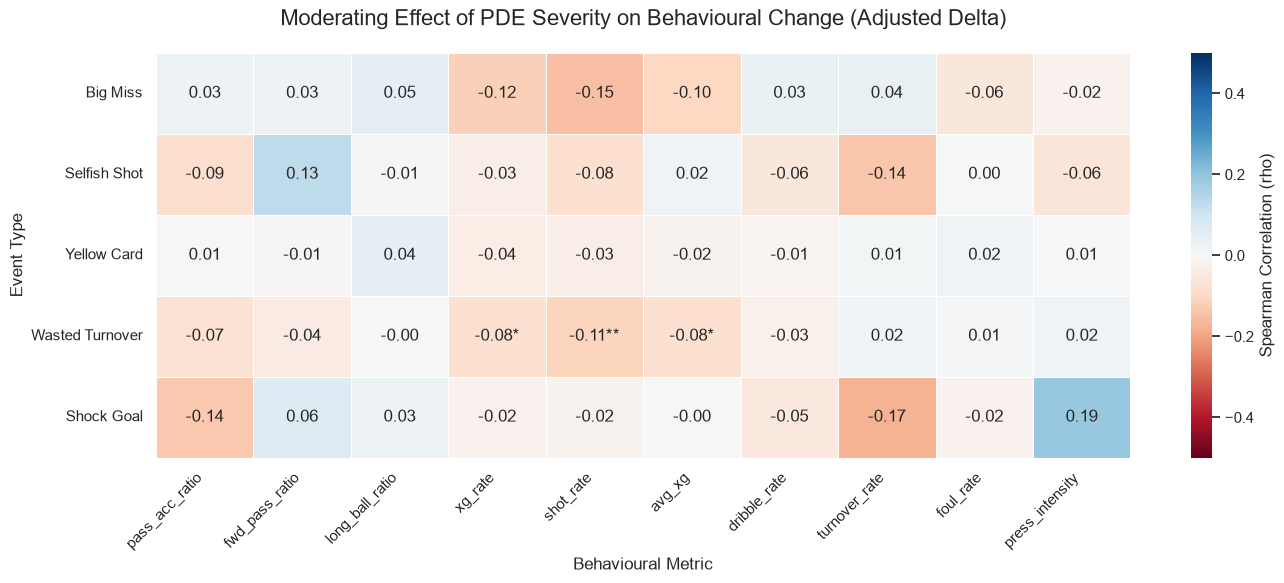


=== Final heatmap summary ===
     event_type          metric  n_obs  spearman_rho  p_value_raw  p_value_fdr  is_significant
Wasted Turnover       shot_rate   1459     -0.111313     0.000020     0.001016            True
Wasted Turnover          avg_xg   1459     -0.080616     0.002059     0.046936            True
Wasted Turnover         xg_rate   1459     -0.078151     0.002816     0.046936            True
Wasted Turnover  pass_acc_ratio   1459     -0.074869     0.004219     0.052734           False
       Big Miss       shot_rate    293     -0.148768     0.010778     0.107782           False
     Shock Goal press_intensity    149      0.190262     0.020117     0.167645           False
     Shock Goal   turnover_rate    149     -0.173497     0.034342     0.245298           False
       Big Miss         xg_rate    293     -0.119895     0.040276     0.251725           False
   Selfish Shot   turnover_rate    177     -0.137199     0.068607     0.372477           False
       Big Miss    

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Reuse the same adjusted delta and standardized severity analysis.
# The goal here is the heatmap output matching the original specification.

# Load the same inputs.
pde_df = pd.read_csv('output/pde/catalogue/events_with_metrics.csv')
control_df = pd.read_csv('output/pde/controls/controls_with_metrics.csv')

metrics = [
    'pass_acc_ratio', 'fwd_pass_ratio', 'long_ball_ratio', 'xg_rate',
    'shot_rate', 'avg_xg', 'dribble_rate', 'turnover_rate',
    'foul_rate', 'press_intensity'
]

event_types = ['Big Miss', 'Selfish Shot', 'Yellow Card', 'Wasted Turnover', 'Shock Goal']

control_deltas = []
for metric in metrics:
    delta_col = f'delta_{metric}'
    avg_ctrl = control_df.groupby('paired_event_id')[delta_col].mean().rename(f'avg_ctrl_delta_{metric}')
    control_deltas.append(avg_ctrl)

control_agg_df = pd.concat(control_deltas, axis=1).reset_index()
control_agg_df.rename(columns={'paired_event_id': 'event_id'}, inplace=True)

pde_adj_df = pde_df.merge(control_agg_df, on='event_id', how='left')
for metric in metrics:
    pde_adj_df[f'adj_delta_{metric}'] = pde_adj_df[f'delta_{metric}'] - pde_adj_df[f'avg_ctrl_delta_{metric}']

pde_adj_df['severity_std'] = (
    pde_adj_df.groupby('event_type')['severity']
    .transform(lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) != 0 else 0.0)
    .fillna(0.0)
)

correlation_results = []
for event in event_types:
    event_data = pde_adj_df[pde_adj_df['event_type'] == event].copy()
    for metric in metrics:
        adj_delta_col = f'adj_delta_{metric}'
        valid_data = event_data[['severity_std', adj_delta_col]].dropna()

        if len(valid_data) < 5:
            rho, p_val = np.nan, np.nan
        else:
            rho, p_val = spearmanr(valid_data['severity_std'], valid_data[adj_delta_col])

        correlation_results.append({
            'event_type': event,
            'metric': metric,
            'n_obs': len(valid_data),
            'spearman_rho': rho,
            'p_value_raw': p_val
        })

corr_df = pd.DataFrame(correlation_results)
reject, pvals_corrected, _, _ = multipletests(
    pvals=corr_df['p_value_raw'].fillna(1.0),
    alpha=0.05,
    method='fdr_bh'
)
corr_df['p_value_fdr'] = pvals_corrected
corr_df['is_significant'] = reject

heatmap_data = corr_df.pivot(index='event_type', columns='metric', values='spearman_rho')
pval_data = corr_df.pivot(index='event_type', columns='metric', values='p_value_fdr')
heatmap_data = heatmap_data.reindex(index=event_types, columns=metrics)
pval_data = pval_data.reindex(index=event_types, columns=metrics)

annot_data = heatmap_data.copy().astype(str)
for row in heatmap_data.index:
    for col in heatmap_data.columns:
        rho_val = heatmap_data.loc[row, col]
        p_val = pval_data.loc[row, col]

        if pd.isna(rho_val):
            annot_data.loc[row, col] = ''
            continue

        stars = ''
        if p_val < 0.001:
            stars = '***'
        elif p_val < 0.01:
            stars = '**'
        elif p_val < 0.05:
            stars = '*'

        annot_data.loc[row, col] = f'{rho_val:.2f}{stars}'

plt.figure(figsize=(14, 6))
sns.set_theme(style='white')
ax = sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt='',
    cmap='RdBu',
    vmin=-0.5,
    vmax=0.5,
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Spearman Correlation (rho)'}
)

plt.title('Moderating Effect of PDE Severity on Behavioural Change (Adjusted Delta)', fontsize=16, pad=20)
plt.xlabel('Behavioural Metric', fontsize=12)
plt.ylabel('Event Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('output/pde/analysis/severity_correlation_heatmap.png', dpi=300)
plt.show()

print('\n=== Final heatmap summary ===')
print(corr_df[['event_type', 'metric', 'n_obs', 'spearman_rho', 'p_value_raw', 'p_value_fdr', 'is_significant']].sort_values('p_value_raw').to_string(index=False))